# Cross-Condition Analysis

## Packages

Note: To run this analysis you will need to install ParTIpy with the tutorial extras: `pip install partipy[extra]`.

In [1]:
from pathlib import Path

import plotnine as pn
import scanpy as sc
import partipy as pt

import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from mizani.bounds import squish
import decoupler as dc
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import harmonypy as hm
from scipy.stats import ttest_ind
from scipy.optimize import linear_sum_assignment

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Motivation

Cross-condition analyses are a central component of single-cell transcriptomic studies and are commonly performed by discretizing cells into clusters followed by tests for condition-dependent changes in cluster abundance or gene expression. While effective in many settings, such approaches impose sharp boundaries on cell states that are often intrinsically continuous. ParTIpy enables an alternative formulation by modeling cells as continuous mixtures of archetypal programs (“tasks”), thereby enabling the testing of shifts within the task space across conditions.

## Data

To illustrate this workflow, we will analyize single-nucleus RNA-seq data from human adult heart tissue comprising 16 non-failing (NF) donor hearts and 26 cardiomyopathy (CM; pooled hypertrophic and dilated cardiomyopathy) hearts, focusing on approximately 147,000 fibroblasts from {cite:p}`chaffin2022`.

Fibroblasts are particularly well suited for this analysis, as they exhibit pronounced disease-associated transcriptional remodeling and span a continuum from quiescent ECM maintenance to activated, fibrotic programs in cardiomyopathy.

The adata object must be manually downloaded from: https://singlecell.broadinstitute.org/single_cell/study/SCP1303/single-nuclei-profiling-of-human-dilated-and-hypertrophic-cardiomyopathy#study-download

In [2]:
adata = sc.read_h5ad(Path("data") / "human_dcm_hcm_scportal_03.17.2022.h5ad")

# 1) subset to fibroblasts
adata = adata[
    adata.obs["cell_type_leiden0.6"].isin(["Fibroblast_I", "Activated_fibroblast", "Fibroblast_II"]),
    :,
].copy()

# 2) map HCM and DCM to CM
adata.obs["disease_original"] = adata.obs["disease"].copy()
adata.obs["disease"] = adata.obs["disease_original"].map({"HCM": "CM", "DCM": "CM", "NF": "NF"})

# 3) define color dict for plotting later
color_dict = {
    "NF": "#01665E",
    "CM": "#8C510A",
}

# 4) check that data has counts
assert np.all(np.isclose(adata.X.data, np.round(adata.X.data)))

# 5) save some memory
del adata.layers["cellranger_raw"]
del adata.obsm["X_umap"]

adata

AnnData object with n_obs × n_vars = 147219 × 36601
    obs: 'biosample_id', 'donor_id', 'disease', 'sex', 'age', 'lvef', 'cell_type_leiden0.6', 'SubCluster', 'cellbender_ncount', 'cellbender_ngenes', 'cellranger_percent_mito', 'exon_prop', 'cellbender_entropy', 'cellranger_doublet_scores', 'disease_original'
    var: 'gene_ids', 'feature_types', 'genome'

## Preprocessing

Before downstream analysis, we perform standard single-cell RNA-seq quality control.

We first annotate mitochondrial (MT-), ribosomal (RPS, RPL), and hemoglobin (HB) genes and compute canonical QC metrics using scanpy.pp.calculate_qc_metrics, including:
- total counts per cell
- number of detected genes per cell
- percentage of counts attributed to mitochondrial, ribosomal, and hemoglobin genes
- number of cells expressing each gene

Cells with low library size, low gene complexity, or excessive mitochondrial content are filtered.
Genes detected in too few cells are removed.

This ensures that subsequent analyses are not driven by low-quality cells or uninformative genes.

/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_ydensity : Removed 4417 rows containing non-finite values.
/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:39: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 2 values. 3 were requested from it.
/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:39: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 2 values. 3 were requested from it.


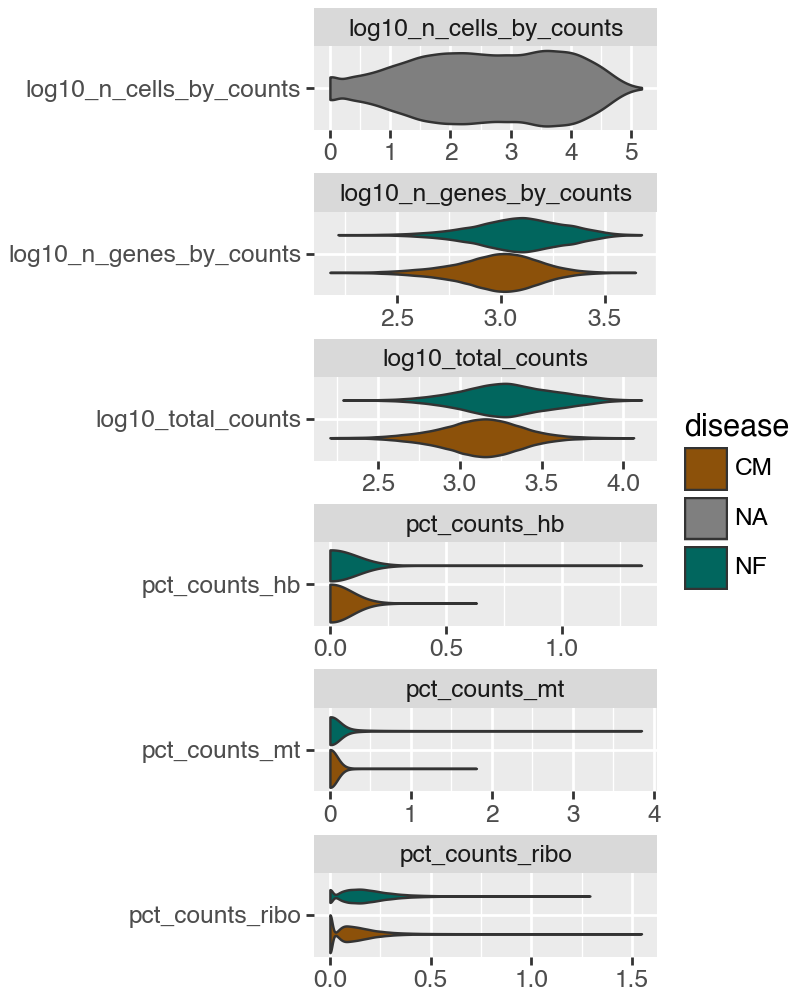

In [3]:
# 1) add bool vector that indicate mitochondrial, ribosomal, and hemoglobin related genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

# 2) compute canonical QC metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=False)
adata.var["log10_n_cells_by_counts"] = np.log10(adata.var["n_cells_by_counts"])
adata.obs["log10_total_counts"] = np.log10(adata.obs["total_counts"])
adata.obs["log10_n_genes_by_counts"] = np.log10(adata.obs["n_genes_by_counts"])

# 3) visualization
qc_vars = ["log10_total_counts", "log10_n_genes_by_counts", "pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"]
plot_df = pd.concat(
    [
        adata.obs.melt(id_vars=["disease"], value_vars=qc_vars),
        adata.var.melt(value_vars=["log10_n_cells_by_counts"]).assign(disease="NA"),
    ]
)
p = (
    pn.ggplot(plot_df)
    + pn.geom_violin(pn.aes(x="variable", y="value", fill="disease"))
    + pn.facet_wrap("variable", nrow=6, scales="free")
    + pn.scale_fill_manual(values=color_dict)
    + pn.theme(figure_size=(4, 5))
    + pn.coord_flip()
    + pn.labs(x="", y="")
)
p.show()

Based on the above plot, we set the following (conservative) QC thresholds:
- Cells: retain cells with total_counts ≥ 300 and with low fractions of mitochondrial, ribosomal, and hemoglobin counts (pct_counts_mt, pct_counts_ribo, pct_counts_hb ≤ 0.5).
- Genes: retain genes detected in at least 200 cells (n_cells_by_counts ≥ 200).

/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:39: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 2 values. 3 were requested from it.
/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/site-packages/plotnine/scales/scale_manual.py:39: PlotnineWarning: The palette of scale_fill_manual can return a maximum of 2 values. 3 were requested from it.


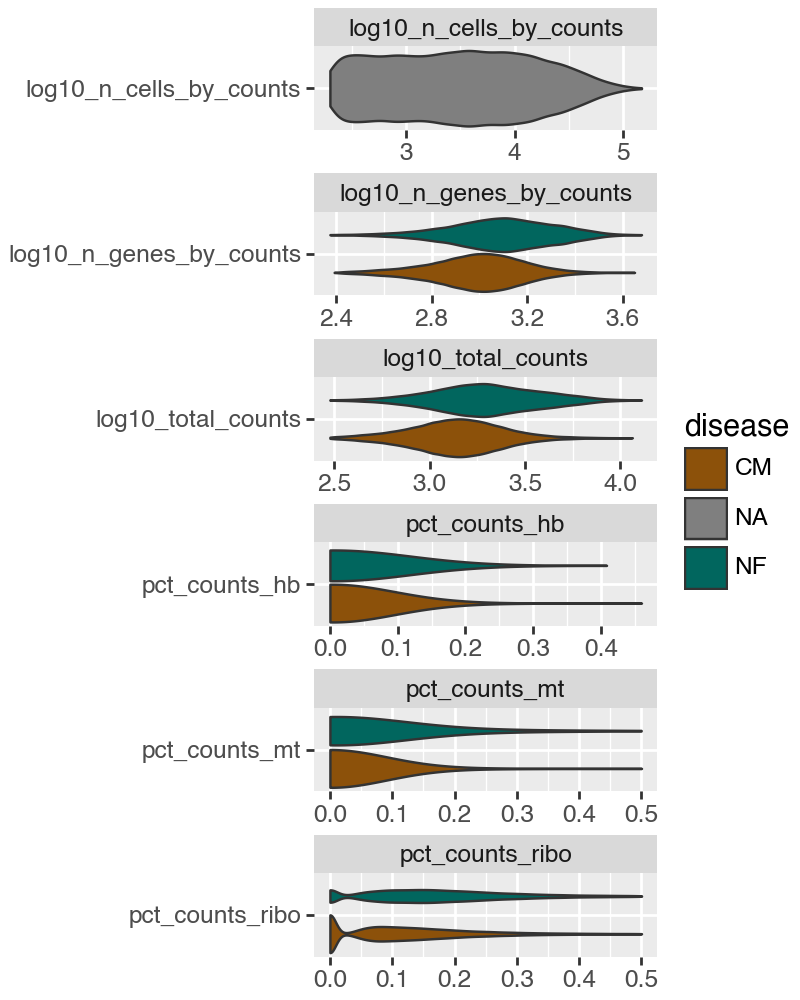

AnnData object with n_obs × n_vars = 142801 × 18866
    obs: 'biosample_id', 'donor_id', 'disease', 'sex', 'age', 'lvef', 'cell_type_leiden0.6', 'SubCluster', 'cellbender_ncount', 'cellbender_ngenes', 'cellranger_percent_mito', 'exon_prop', 'cellbender_entropy', 'cellranger_doublet_scores', 'disease_original', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'log10_total_counts', 'log10_n_genes_by_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log10_n_cells_by_counts'


In [4]:
# 1) set the thresholds
min_counts_per_cell = 300
min_cells_per_gene = 200
max_pct_count_hb = 0.5
max_pct_count_mt = 0.5
max_pct_count_ribo = 0.5

# 2) filter cells
adata = adata[adata.obs["total_counts"] >= min_counts_per_cell, :].copy()
adata = adata[adata.obs["pct_counts_hb"] <= max_pct_count_hb, :].copy()
adata = adata[adata.obs["pct_counts_mt"] <= max_pct_count_mt, :].copy()
adata = adata[adata.obs["pct_counts_ribo"] <= max_pct_count_ribo, :].copy()

# 3) filter genes
adata = adata[:, adata.var["n_cells_by_counts"] >= min_cells_per_gene].copy()

# 4) check
plot_df = pd.concat(
    [
        adata.obs.melt(id_vars=["disease"], value_vars=qc_vars),
        adata.var.melt(value_vars=["log10_n_cells_by_counts"]).assign(disease="NA"),
    ]
)
p = (
    pn.ggplot(plot_df)
    + pn.geom_violin(pn.aes(x="variable", y="value", fill="disease"))
    + pn.facet_wrap("variable", nrow=6, scales="free")
    + pn.scale_fill_manual(values=color_dict)
    + pn.theme(figure_size=(4, 5))
    + pn.coord_flip()
    + pn.labs(x="", y="")
)
p.show()

print(adata)

Before conducting archetypal analysis (AA), we reduce the dimensionality of the scRNA-seq data to suppress technical noise and improve computational efficiency. We first normalize each cell to a common library size using sc.pp.normalize_total, followed by log-transformation with sc.pp.log1p. By default, normalize_total scales each cell to the median total counts across all cells, preserving a typical pre-log expression range.

Next, we select highly variable genes (HVGs) and compute a low-dimensional representation via PCA on HVGs only (here, 50 PCs).

For downstream archetype characterization, we additionally compute a capped z-score transformation (`max_value=10`). This facilitates interpretable aggregation and enrichment analyses at the archetype level. However, storing z-scored expression requires materializing a dense cells × genes matrix, which can be memory-intensive for large datasets.

As a memory-efficient alternative, one can omit storing z-scores and instead use `pt.compute_quantile_based_gene_enrichment` for archetype characterization, which identifies genes enriched near each archetype without requiring a dense matrix. The trade-off is computational time, as the quantile-based procedure is substantially slower.

In [5]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
sc.pp.pca(adata, mask_var="highly_variable", n_comps=50)
adata.layers["z_scaled"] = sc.pp.scale(adata.X, max_value=10).astype(np.float32)
assert adata.layers["z_scaled"].dtype == np.float32

/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.


Furthermore, to account for inter-patient variation, we integrate the data across donors using Harmony. Specifically, we apply Harmony to the PCA embedding with `donor_id` as the batch variable and store the corrected embedding for downstream analyses.

In [6]:
ho = hm.run_harmony(adata.obsm["X_pca"], adata.obs[["donor_id"]], "donor_id", verbose=False)
adata.obsm["X_pca_harmony"] = ho.Z_corr.copy()
del ho

2026-02-16 13:31:00,413 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-02-16 13:31:00 | [INFO] Computing initial centroids with sklearn.KMeans...
2026-02-16 13:31:02,054 - harmonypy - INFO - KMeans initialization complete.
2026-02-16 13:31:02 | [INFO] KMeans initialization complete.


Now, To determine the number of principal components to use for fitting the archetypes, we will examine the scree plot from the PCA. Additionally the plot shows the variance explained if we shuffle the data before computing the PCA. 

Here, the plot indicates that we should only the first 16 principal components.

100%|██████████| 25/25 [05:22<00:00, 12.91s/it]


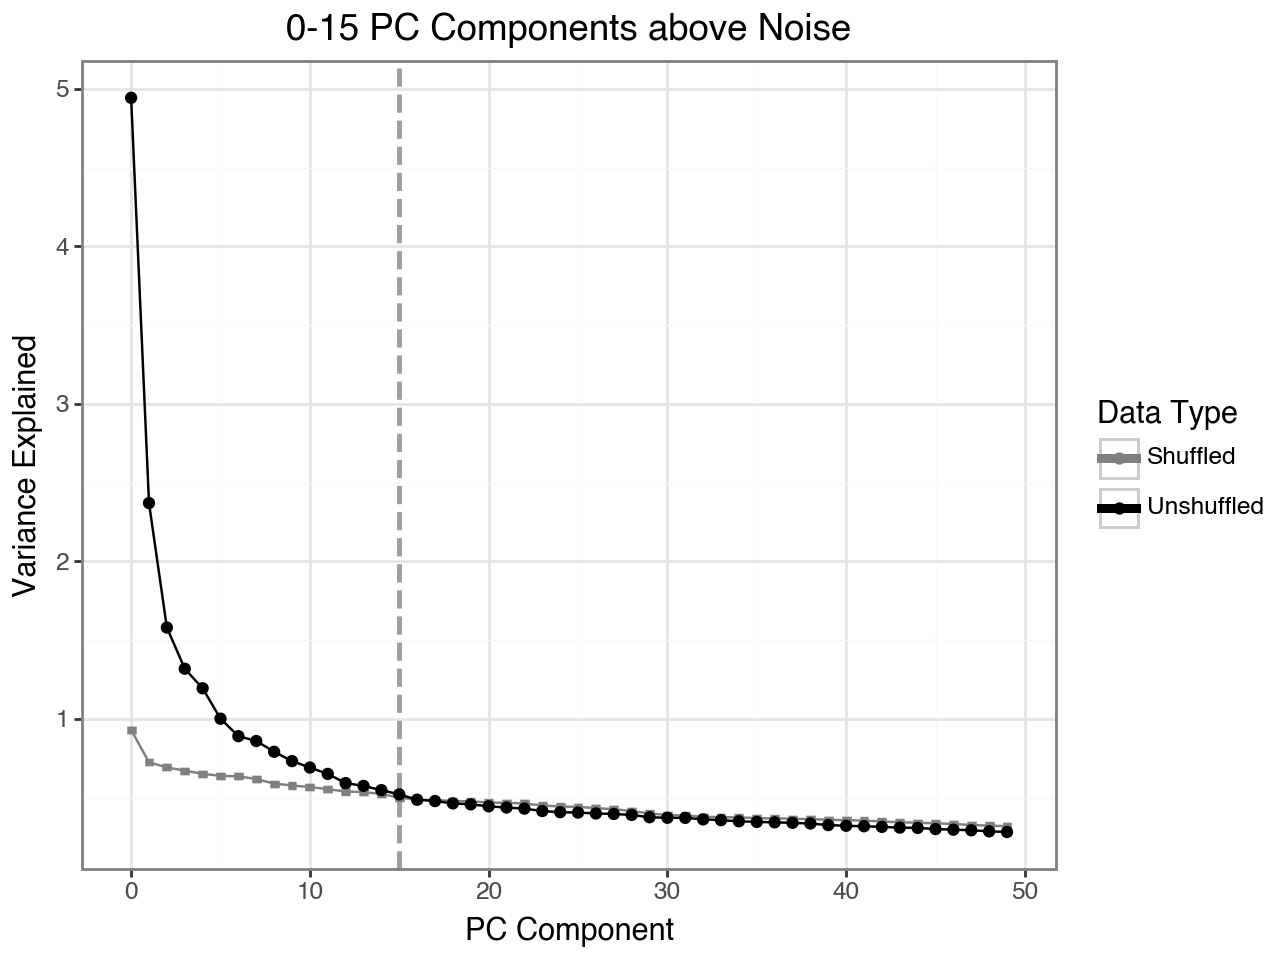

In [7]:
pt.compute_shuffled_pca(adata, mask_var="highly_variable", n_shuffle=25)
p = pt.plot_shuffled_pca(adata) + pn.theme_bw()
p.show()

Based on the above results, we retain the first 16 principal components. Importantly, we explicitly specify that archetypal analysis should be performed on the Harmony-corrected PCA embedding, stored under the obsm_key `X_pca_harmony`.

In [25]:
pt.set_obsm(adata=adata, obsm_key="X_pca_harmony", n_dimensions=16)

## Choosing the Number of Archetypes

Now, we are ready to perform archetypal analysis, but the key question remains: how many archetypes should be used?

There is no definitive ground truth for this choice, but several heuristics can guide the decision. A practical approach is to evaluate selection metrics across a range of archetype counts.

The function `pt.compute_selection_metrics()` evaluates multiple values of `k` (here via `n_archetypes_list=range(2, 9)`) and computes both variance explained and an information criterion suggested by {cite:p}`sulemanValidationArchetypalAnalysis2017`.

The results are cached in `adata.uns["AA_selection_metrics"]` and can be visualized with `pt.plot_var_explained(adata)` and `pt.plot_IC(adata)`. In this example, both diagnostics suggest that choosing 4 archetypes is a reasonable trade-off, since additional variance explained beyond this point is small.

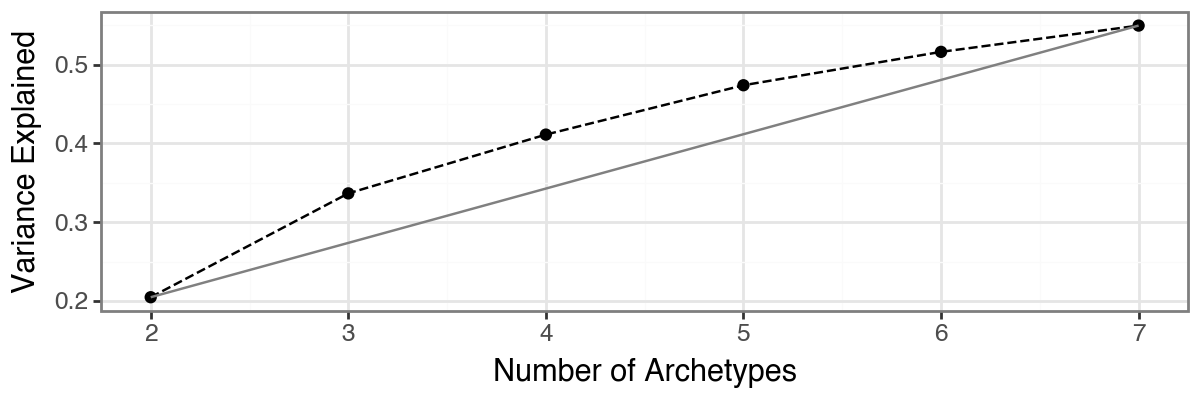

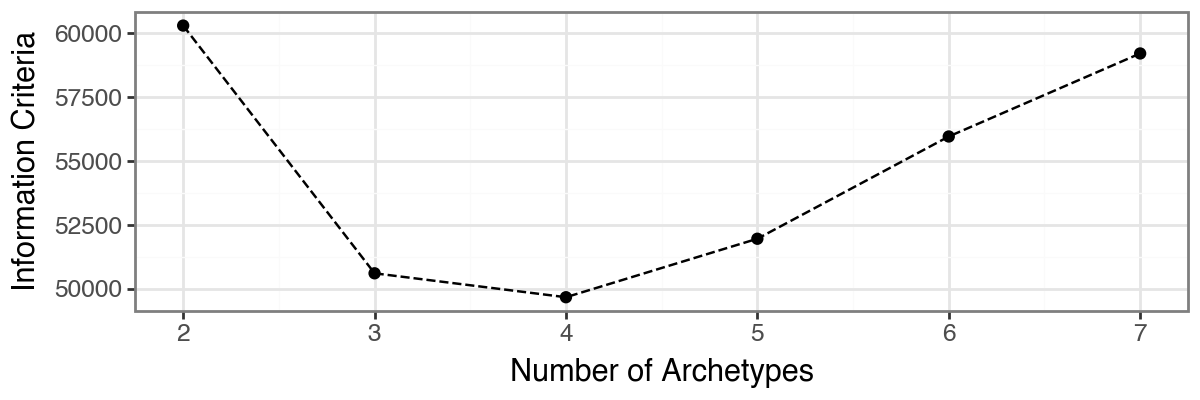

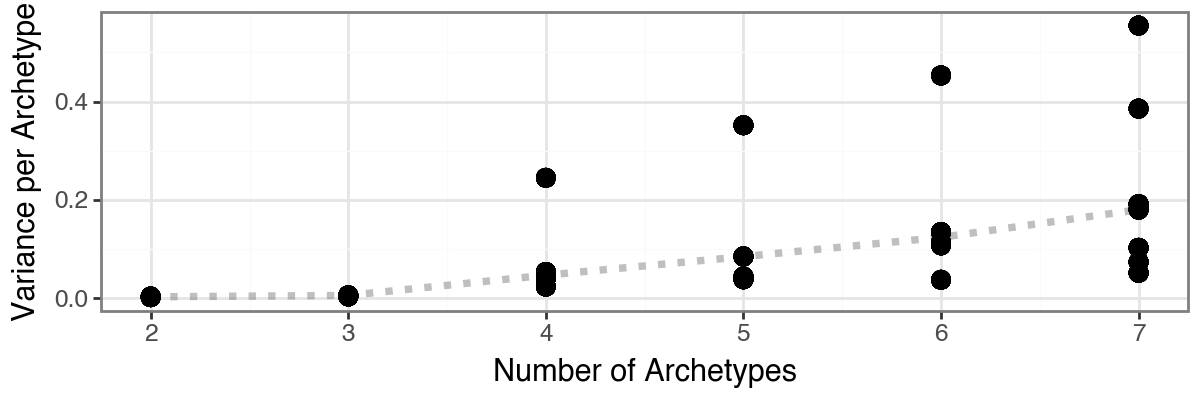

In [9]:
pt.compute_selection_metrics(
    adata=adata, n_archetypes_list=range(2, 8), coreset_algorithm="standard", coreset_fraction=0.05
)
pt.compute_bootstrap_variance(
    adata=adata,
    n_bootstrap=50,
    n_archetypes_list=range(2, 8),
    coreset_algorithm="standard",
    coreset_fraction=0.05,
)

p = pt.plot_var_explained(adata) + pn.theme_bw() + pn.theme(figure_size=(6, 2)) + pn.labs(x="Number of Archetypes")
p.show()

p = pt.plot_IC(adata) + pn.theme_bw() + pn.theme(figure_size=(6, 2)) + pn.labs(x="Number of Archetypes")
p.show()

p = pt.plot_bootstrap_variance(adata) + pn.theme_bw() + pn.theme(figure_size=(6, 2)) + pn.labs(x="Number of Archetypes")
p.show()

Based on the model selection results, we opt for three archetypes.

Although both the proportion of variance explained and the information criterion favored a four-archetype solution, the four-archetype configuration exhibited one archetype with high positional variance across bootstrap replicates, indicating limited robustness. In contrast, the three-archetype model showed slightly reduced reconstruction performance but substantially improved bootstrap stability and reproducibility. This trade-off favors a more robust and biologically interpretable representation of the data.

In [10]:
n_archetypes = 3

Below, we visualize the inferred archetypes projected onto the first two Harmony-corrected principal components. Note, however, that the archetypes were fitted in the full 16-dimensional embedding; the two-dimensional plot is shown purely for visualization purposes.

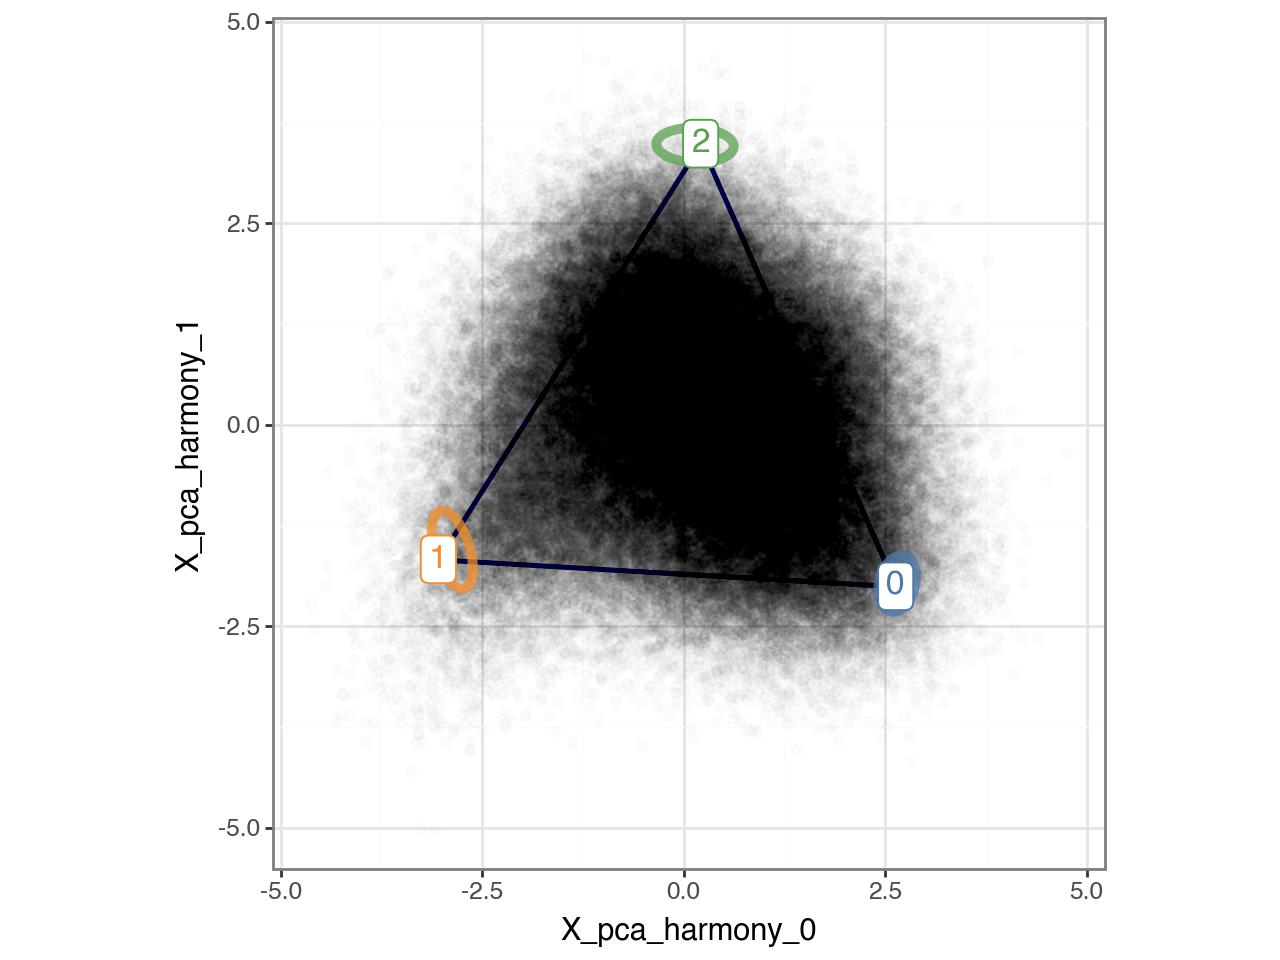

In [11]:
p = (
    pt.plot_archetypes_2D(
        adata=adata,
        show_contours=True,
        result_filters={"n_archetypes": n_archetypes},
        alpha=0.01,
    )
    + pn.theme_bw()
)
p.show()

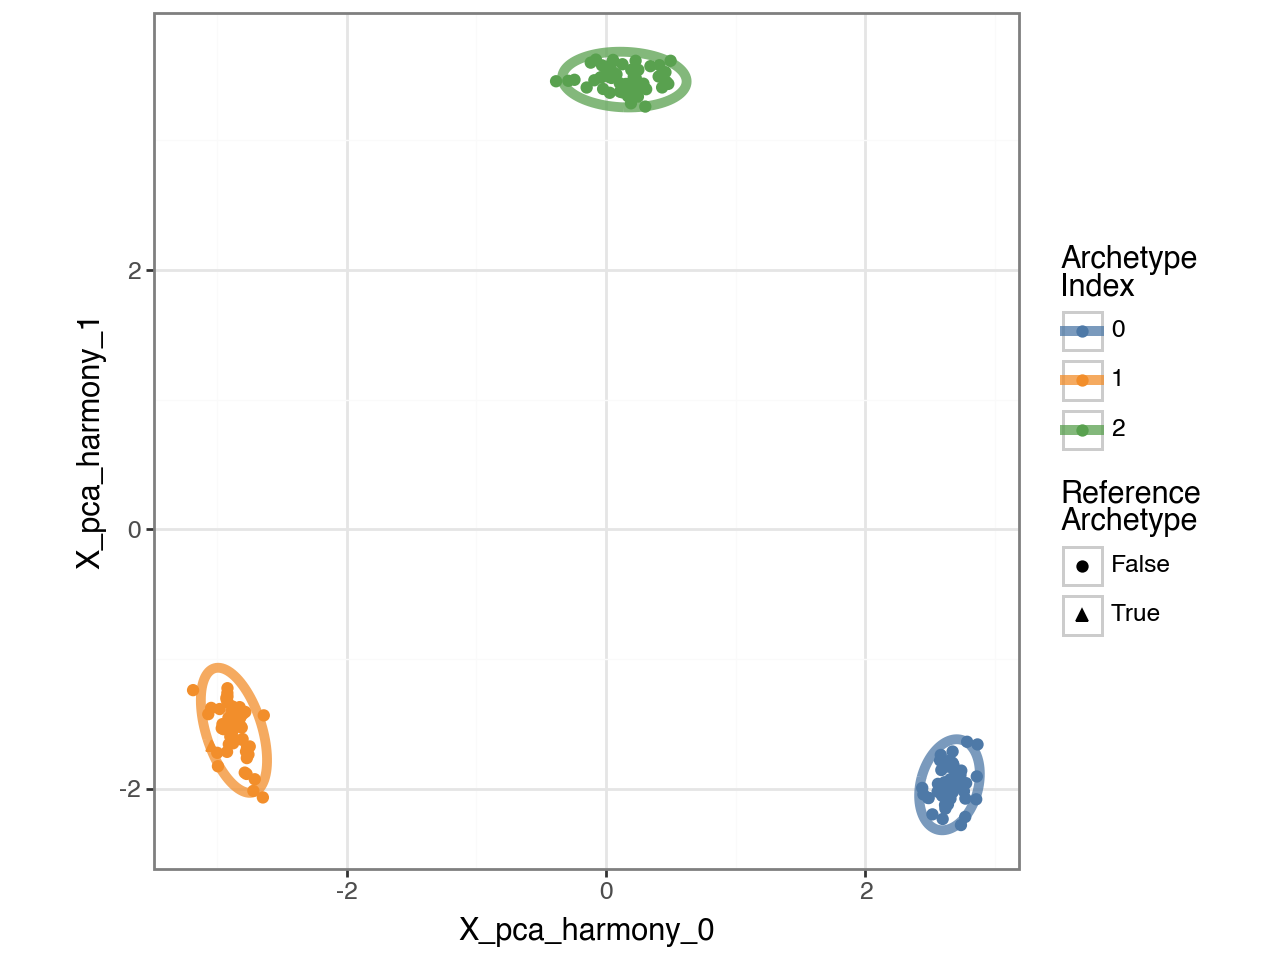

In [12]:
p = pt.plot_bootstrap_2D(adata, result_filters={"n_archetypes": n_archetypes}) + pn.theme_bw()
p.show()

## Cross-Condition Contrast

We can gauge condition enrichment near each archetype using pt.compute_meta_enrichment. This computes, for each archetype k, the relative concentration of cells from each condition (here: disease) among cells with high archetype weights, and visualizes the result as a barplot.

Applied length scale is 1.78.


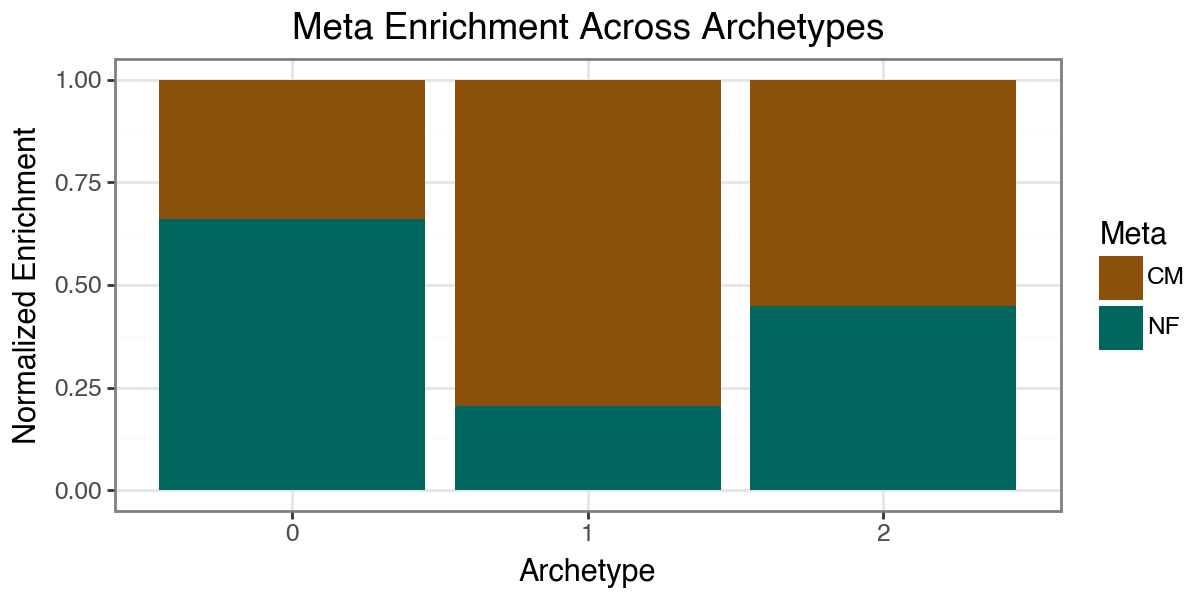

In [13]:
pt.compute_archetype_weights(adata=adata, mode="automatic", result_filters={"n_archetypes": n_archetypes})

disease_enrichment = pt.compute_meta_enrichment(
    adata=adata, meta_col="disease", result_filters={"n_archetypes": n_archetypes}
)
p = pt.barplot_meta_enrichment(disease_enrichment, color_map=color_dict) + pn.theme_bw() + pn.theme(figure_size=(6, 3))
p.show()

To avoid pseudo-replication and ensure valid statistical inference, we quantify shifts in task allocation at the **donor level** rather than at the single-cell level.

Let $\mathbf{X} \in \mathbb{R}^{N \times D}$ denote the Harmony-corrected PCA embedding used for archetype inference (with $D=16$ in this analysis), and let $\mathbf{Z} \in \mathbb{R}^{K \times D}$ denote the learned archetype matrix.

**1. Donor-level aggregation**

Let $\mathcal{I}_d \subset \{1,\dots,N\}$ denote the index set of fibroblast cells originating from donor $d$, and let $n_d = |\mathcal{I}_d|$.  
We compute the donor-level mean embedding

$$
\bar{\mathbf{x}}_d
=
\frac{1}{n_d}
\sum_{n \in \mathcal{I}_d}
\mathbf{x}_n
\;\in\;
\mathbb{R}^{D}.
$$

This yields one low-dimensional representation per donor, summarizing the average fibroblast task allocation.

**2. Projection onto the archetypal simplex**

For each donor $d$, we estimate donor-level archetype weights
$\boldsymbol{\alpha}_d \in \Delta_{K-1}$ by solving

$$
\boldsymbol{\alpha}_d
=
\underset{\boldsymbol{\alpha} \in \Delta_{K-1}}{\arg\min}
\left\|
\bar{\mathbf{x}}_d
-
\boldsymbol{\alpha} \mathbf{Z}
\right\|_2^2,
$$

where $\Delta_{K-1}$ denotes the standard $(K-1)$-simplex.  
The corresponding reconstruction is

$$
\hat{\mathbf{x}}_d
=
\boldsymbol{\alpha}_d \mathbf{Z}.
$$

Thus, $\boldsymbol{\alpha}_d$ represents the mean donor-level task allocation in archetypal coordinates.

**3. Donor-level proximity to archetypes**

For each donor $d$ and archetype $k \in \{1,\dots,K\}$, we compute the Euclidean distance between the reconstructed donor embedding and archetype $k$:

$$
D_{dk}
=
\left\|
\hat{\mathbf{x}}_d
-
\mathbf{z}_k
\right\|_2.
$$

The matrix $\mathbf{D} \in \mathbb{R}^{D_{\text{donor}} \times K}$ therefore quantifies donor-level proximity to each task-specialized state.

**4. Statistical comparison across conditions**

Let $\mathcal{D}_{\mathrm{CM}}$ and $\mathcal{D}_{\mathrm{NF}}$ denote the sets of cardiomyopathy (CM) and non-failing (NF) donors, respectively.

For each archetype $k$, we compare $\{D_{dk}\}_{d \in \mathcal{D}_{\mathrm{CM}}}$ and $\{D_{dk}\}_{d \in \mathcal{D}_{\mathrm{NF}}}$ using a two-sided Welch’s $t$-test, which does not assume equal variances between groups.

Multiple testing across archetypes is controlled using the Benjamini–Hochberg procedure to control the false discovery rate.

/var/folders/n8/xnf8qmpj41795tf723xy8mqm0000gn/T/ipykernel_44448/3122129156.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


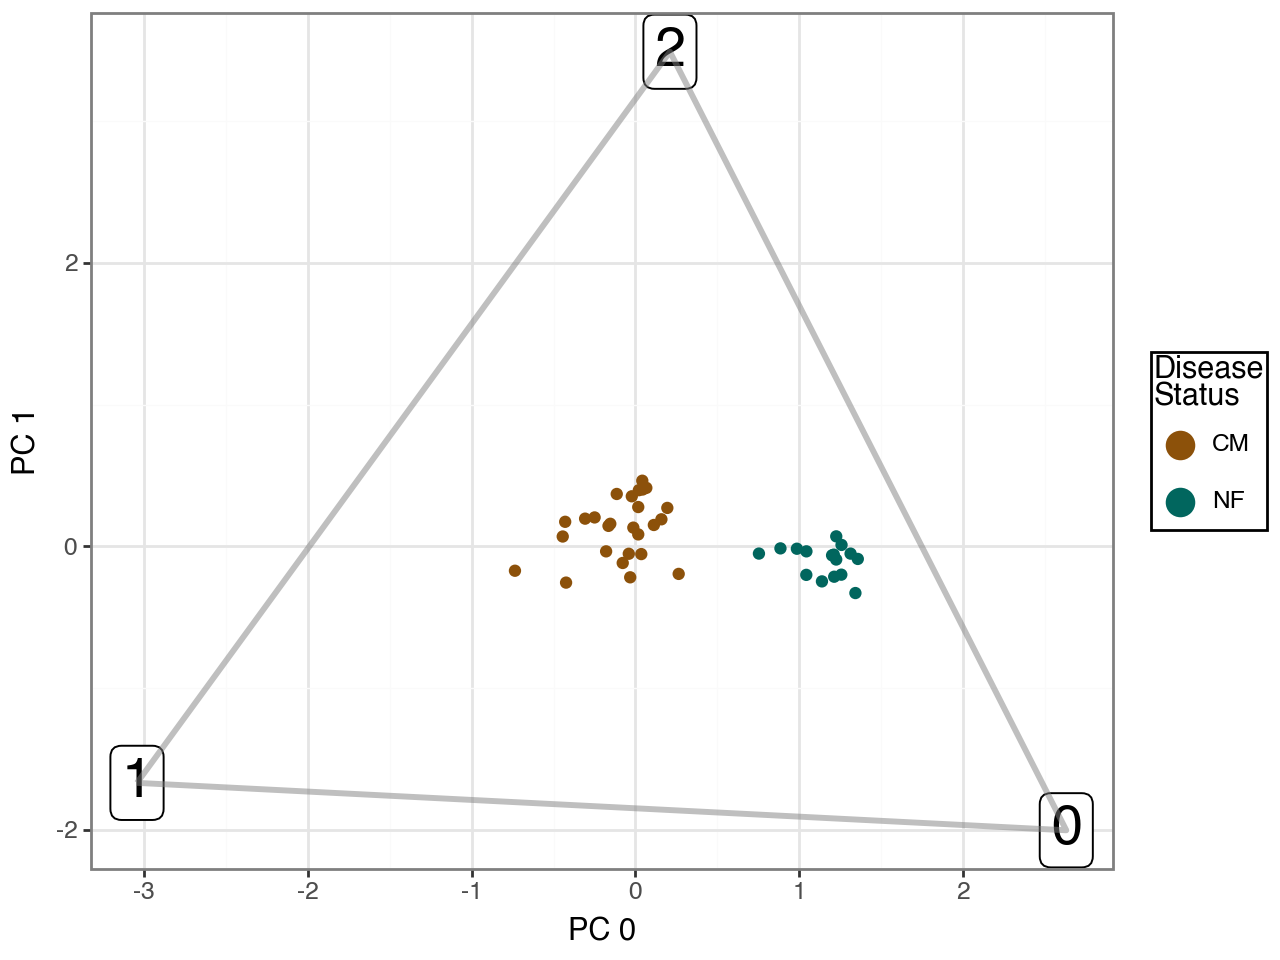

In [14]:
# 1) get the archetypes
aa_results_dict = pt.get_aa_result(adata, n_archetypes=n_archetypes)
Z = aa_results_dict["Z"].copy().astype(np.float32)
archetype_df = pd.DataFrame(Z, columns=[f"pc_{arch_idx}" for arch_idx in range(Z.shape[1])])
archetype_df["archetype"] = [f"{idx}" for idx in range(len(archetype_df))]

# 2) get the single-cell data (note adata.uns["AA_config"]["n_dimensions"] is a list of ints)
X = adata.obsm[adata.uns["AA_config"]["obsm_key"]][:, adata.uns["AA_config"]["n_dimensions"]].copy().astype(np.float32)

# 3) aggregate per patient
cols_to_check = ["disease"] + ["donor_id"]
nuniq = adata.obs.groupby("donor_id")[cols_to_check].nunique(dropna=False)
assert (nuniq.max() <= 1).all(), f"Non-unique covariates within sample_id:\n{nuniq.max()[nuniq.max() > 1]}"
obs_agg = adata.obs[cols_to_check].drop_duplicates().copy()
X_agg = np.zeros((len(obs_agg), X.shape[1]), dtype=np.float32)
for idx, smp_id in enumerate(obs_agg["donor_id"]):
    X_agg[idx, :] = X[adata.obs["donor_id"] == smp_id, :].mean(axis=0)

# 4) project onto the convex hull
AA_model = pt.AA(n_archetypes=len(Z))
AA_model.Z = Z
AA_model.n_samples = len(X_agg)
X_agg_proj = AA_model.transform(X_agg)
assert np.all(np.isclose(X_agg_proj.sum(axis=1), 1))
assert np.all(X_agg_proj >= 0)
X_agg_conv = X_agg_proj @ Z

# 5) add first 3 pcs to obs_agg for plotting
for pc_idx in [0, 1, 2]:
    obs_agg[f"pc_{pc_idx}"] = X_agg_conv[:, pc_idx]

# O) plotting
hull = ConvexHull(archetype_df[["pc_0", "pc_1"]].to_numpy())
hull_points = archetype_df.iloc[hull.vertices][["pc_0", "pc_1"]]
hull_df = pd.concat([hull_points, hull_points.iloc[:1]], ignore_index=True)
p = (
    (
        pn.ggplot()
        + pn.geom_point(data=obs_agg, mapping=pn.aes(x="pc_0", y="pc_1", color="disease"))
        + pn.geom_point(
            data=archetype_df,
            mapping=pn.aes(x="pc_0", y="pc_1"),
            color="grey",
            alpha=0.5,
            size=2,
        )
        + pn.geom_label(
            data=archetype_df,
            mapping=pn.aes(x="pc_0", y="pc_1", label="archetype"),
            color="black",
            fill="white",
            boxcolor="black",
            label_r=0.2,
            label_padding=0.2,
            label_size=0.7,
            size=20,
        )
    )
    + pn.theme_bw()
    + pn.guides(color=pn.guide_legend(override_aes={"alpha": 1.0, "size": 5}))
    + pn.scale_color_manual(values=color_dict)
    + pn.labs(x="PC 0", y="PC 1", color="Disease\nStatus")
    + pn.theme(
        legend_key=pn.element_rect(fill="white", color="white"),
        legend_background=pn.element_rect(fill="white", color="black"),
    )
)
p += pn.geom_path(
    data=hull_df,
    mapping=pn.aes(x="pc_0", y="pc_1"),
    color="grey",
    size=1.2,
    alpha=0.5,
)
p.show()

And, then we compute distances and perform statistical tests.

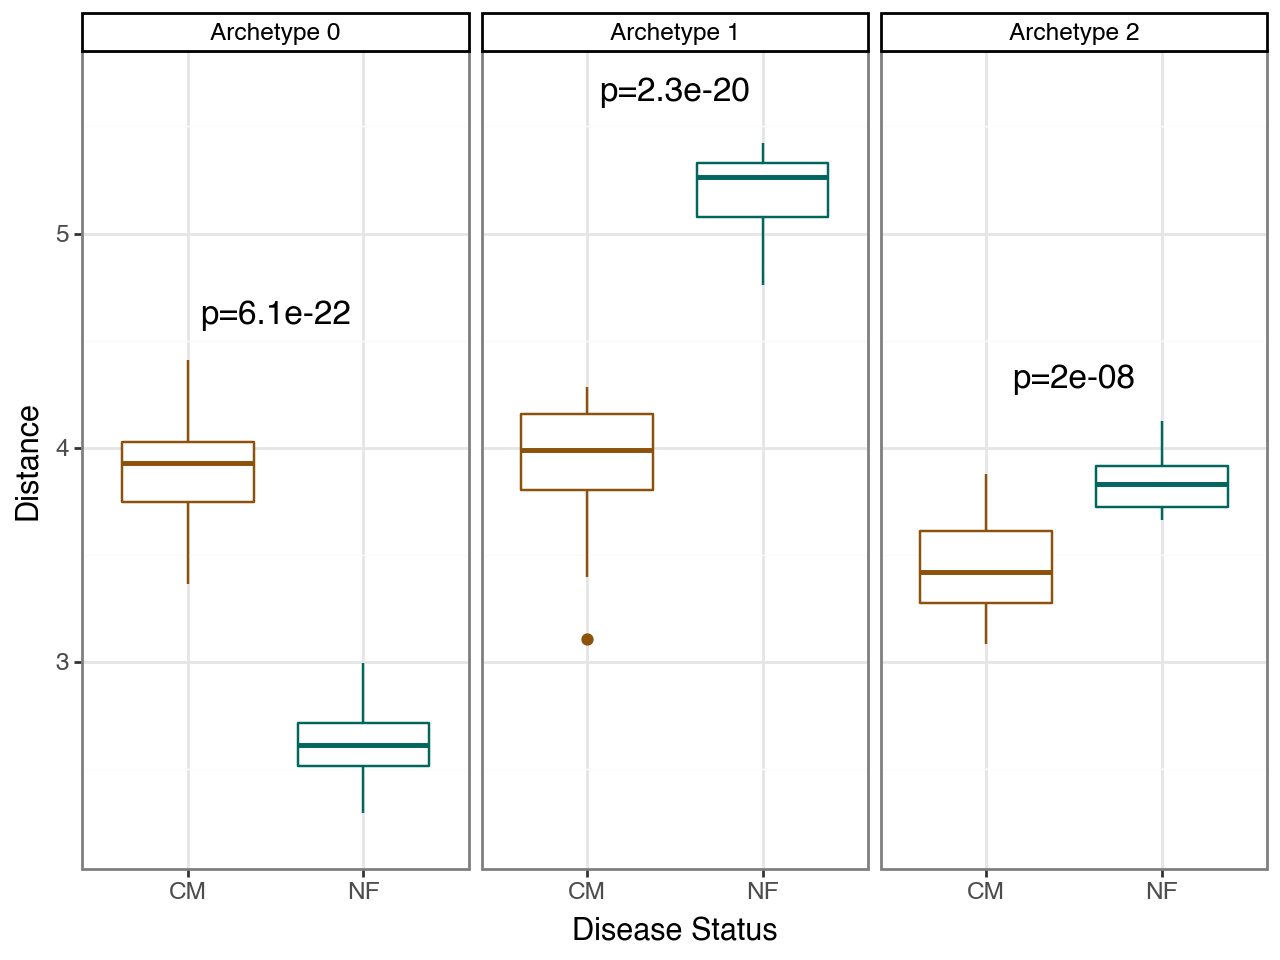

In [15]:
# 6) compute the distance matrix
dist_key = "euclidean"
D = cdist(XA=X_agg_conv, XB=Z, metric=dist_key)

# 7) add distance to the dataframe
for arch_idx in range(len(Z)):
    obs_agg[f"dist_to_arch_{arch_idx}"] = D[:, arch_idx]

# O) More plotting
dist_cols = [c for c in obs_agg.columns if c.startswith("dist_to_arch_")]
plot_df = obs_agg.melt(id_vars=["donor_id", "disease"], value_vars=dist_cols)
plot_df["variable_clean"] = [s.replace("dist_to_arch_", "Archetype ") for s in plot_df["variable"]]

# a) Welch's t-test
dist_cols = [c for c in obs_agg.columns if c.startswith("dist_to_arch_")]
g0, g1 = "NF", "CM"

# ---------------------------
rows = []
for c in dist_cols:
    x = obs_agg.loc[obs_agg["disease"] == g0, c].astype(float).dropna().to_numpy()
    y = obs_agg.loc[obs_agg["disease"] == g1, c].astype(float).dropna().to_numpy()

    tstat, pval = ttest_ind(x, y, equal_var=False, nan_policy="omit")  # Welch

    rows.append(
        {
            "dist_col": c,
            "group0": g0,
            "group1": g1,
            "n0": x.size,
            "n1": y.size,
            "mean0": np.mean(x) if x.size else np.nan,
            "mean1": np.mean(y) if y.size else np.nan,
            "diff_mean_0_minus_1": (np.mean(x) - np.mean(y)) if (x.size and y.size) else np.nan,
            "t": tstat,
            "p": pval,
        }
    )

ttest_results = pd.DataFrame(rows)
reject, qvals, _, _ = multipletests(ttest_results["p"].values, alpha=0.05, method="fdr_bh")
ttest_results["q"] = qvals
ttest_results["reject_fdr_0p05"] = reject

# O) boxplot with p-values from t-test
ann = ttest_results.assign(
    variable_clean=lambda d: d["dist_col"].str.replace("dist_to_arch_", "Archetype ", regex=False),
    label=lambda d: d["p"].map(lambda p: f"p={p:.2g}"),
).loc[:, ["variable_clean", "label"]]
ypos = plot_df.groupby("variable_clean")["value"].max().reset_index(name="ymax")
ypos["y"] = ypos["ymax"] * 1.03  # increase y-limit by ~8%

ann = ann.merge(ypos[["variable_clean", "y"]], on="variable_clean", how="left")

p = (
    pn.ggplot(plot_df)
    + pn.geom_boxplot(
        pn.aes(x="disease", y="value", color="disease"),
        show_legend=False,
    )
    + pn.geom_text(
        data=ann,
        mapping=pn.aes(x=1.5, y="y", label="label"),
        inherit_aes=False,
        size=12,
        ha="center",
        va="bottom",
    )
    + pn.facet_wrap("variable_clean", ncol=n_archetypes)
    + pn.scale_color_manual(values=color_dict)
    + pn.scale_y_continuous(expand=(0.05, 0.10))
    + pn.theme_bw()
    + pn.theme(
        strip_background=pn.element_rect(fill="white", color="black"),
        strip_text=pn.element_text(color="black"),
    )
    + pn.labs(x="Disease Status", y="Distance")
)
p.show()

This analysis shows that distances to all three archetypes differed significantly between conditions. The strongest differences were observed for archetype 0, which was closer to NF donors, and archetype 1, which was closer to CM donors, whereas shifts along archetype 2 were comparatively less pronounced.

The key question, however, is whether archetype 1 represents a CM-specific state or rather a task that is already present in healthy tissue but becomes expanded in disease. To address this, we examined cell-level assignments by (i) assigning each fibroblast to its dominant archetype (the archetype with maximum weight) and (ii) quantifying, for each donor, the number and fraction of cells whose dominant archetype is 1. We then visualize these counts across NF donors.

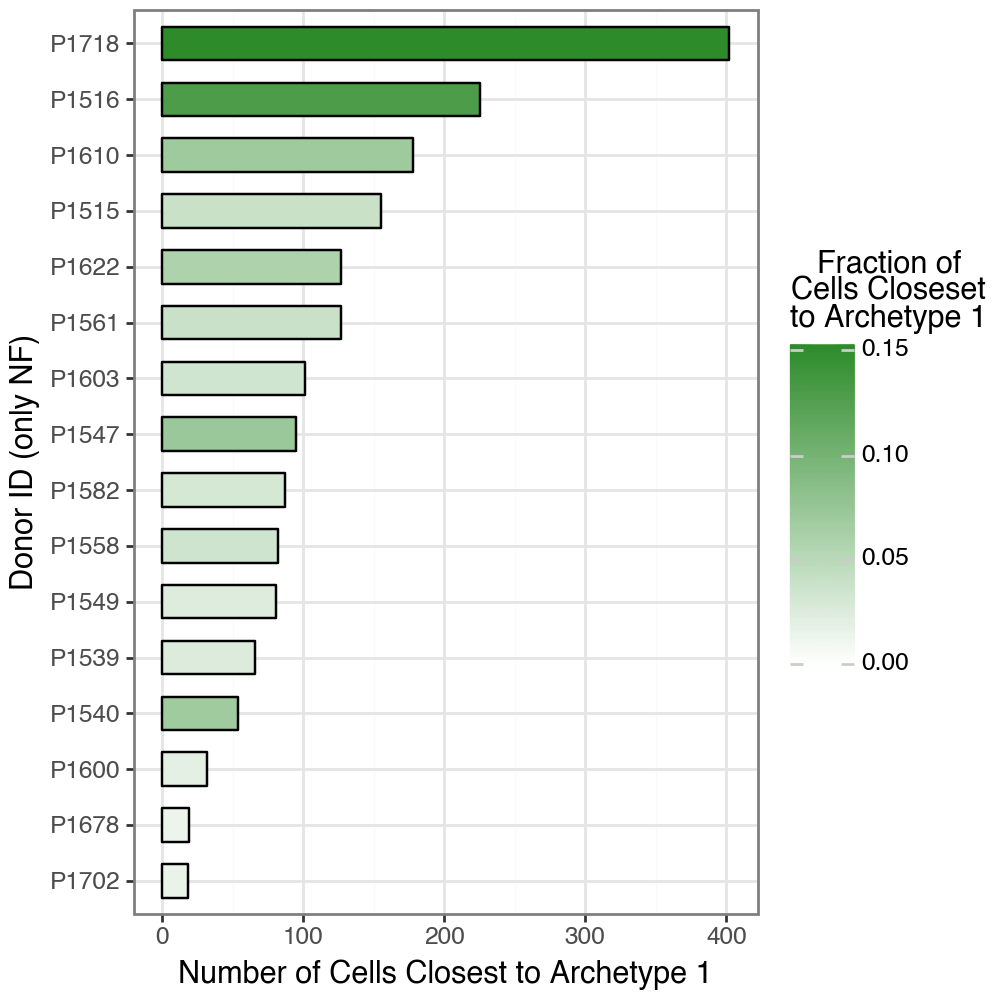

In [27]:
aa_out = pt.get_aa_result(adata, n_archetypes=3)
adata.obs["archetype_max_weight"] = aa_out["A"].argmax(axis=1)
del aa_out
df = (
    adata.obs.value_counts(["disease", "donor_id", "archetype_max_weight"])
    .reset_index()
    .query("archetype_max_weight==1")
    .join(
        adata.obs.value_counts("donor_id").reset_index().rename(columns={"count": "total_cells"}).set_index("donor_id"),
        on="donor_id",
    )
)
df["fraction"] = df["count"] / df["total_cells"]

df_nf = df.query("disease=='NF'").copy()
df_nf = df_nf.sort_values("count", ascending=False)
df_nf["donor_id"] = pd.Categorical(
    df_nf["donor_id"],
    categories=df_nf["donor_id"],
    ordered=True,
)

order = df_nf.sort_values("count", ascending=False)["donor_id"].tolist()

p = (
    pn.ggplot(df_nf)
    + pn.geom_col(pn.aes(x="donor_id", y="count", fill="fraction"), width=0.60, color="black")
    + pn.scale_x_discrete(limits=order[::-1])  # reverse so largest ends up on top after coord_flip
    + pn.coord_flip()
    + pn.theme_bw()
    + pn.labs(
        x="Donor ID (only NF)",
        y="Number of Cells Closest to Archetype 1",
        fill="Fraction of\nCells Closeset\nto Archetype 1",
    )
    + pn.scale_fill_gradient2(
        low="#f7fbff",  # very light
        high="#2d8b2a",  # dark
        limits=(0, df_nf["fraction"].max()),
        oob=squish,
    )
    + pn.theme(
        figure_size=(5, 5),
    )
)
p.show()

This shows that the enrichment of archetype 1 in CM does not imply disease exclusivity. Although CM donors were, on average, closer to archetype 1, every NF donor also contained a subset of fibroblasts whose dominant archetype assignment was archetype 1 (median $\approx 115$ cells per donor), as quantified in the code chunk below. Thus, archetype 1 represents a task that is already present at low frequency in healthy tissue and becomes expanded in cardiomyopathy, rather than a state that emerges de novo in disease.

## Characterizing the Archetypes

To interpret the inferred archetypes, we examine their **characteristic gene-expression profiles**.

Following the definition in the Supplementary Methods (Section *Archetype Characterization*), each archetype is associated with a smooth kernel-based weighting over cells in latent space. These weights are then used to compute a weighted average of gene expression, yielding an archetype-level expression profile.

Concretely, for each archetype $k$, this results in a vector
$$
\boldsymbol{\mu}_k \in \mathbb{R}^{G},
$$
where $\mu_{kg}$ reflects the expression of gene $g$ in cells proximal to archetype $k$.

In practice, `pt.compute_archetype_expression` implements this procedure and returns a matrix (rows = archetypes, columns = genes).

For interpretation, we compute archetype-level expression using:

- log1p-normalized expression (for interpretability in original scale), and  
- z-scored log1p expression (to highlight genes that distinguish archetypes).

We then reshape the resulting tables into long format for downstream ranking and visualization.

In [17]:
arch_expr = {
    "log1p": pt.compute_archetype_expression(adata=adata, layer=None),  # assumes log1p in .X
    "z_scaled": pt.compute_archetype_expression(adata=adata, layer="z_scaled"),
}

long_parts = []
for scale, df_wide in arch_expr.items():
    part = (
        df_wide.rename_axis(index="archetype")
        .reset_index()
        .melt(id_vars="archetype", var_name="gene", value_name="value")
    )
    part["scale"] = scale
    long_parts.append(part)

arch_expr_long = pd.concat(long_parts, ignore_index=True)

arch_expr_long = arch_expr_long.pivot_table(values="value", index=["archetype", "gene"], columns="scale").reset_index()
arch_expr_long.columns.name = None
arch_expr_long

,archetype,gene,log1p,z_scaled
0,0,A1BG,0.006025,-0.029052
1,0,A1BG-AS1,0.005759,-0.029506
2,0,A2M,0.068964,0.018800
3,0,A2M-AS1,0.001273,-0.021838
4,0,A2ML1,0.005275,-0.021734
...,...,...,...,...
56593,2,ZXDC,0.115507,-0.006472
56594,2,ZYG11A,0.002500,-0.019331
56595,2,ZYG11B,0.091982,0.005101
56596,2,ZYX,0.022455,-0.021403


Let's print the top 10 genes per archetype.

In [18]:
for arch_idx in range(n_archetypes):
    display(arch_expr_long.query(f"archetype=={arch_idx}").sort_values("z_scaled", ascending=False).head(12).round(2))

,archetype,gene,log1p,z_scaled
9533,0,KAZN,1.00,0.57
12027,0,NEAT1,1.71,0.33
13923,0,PXDNL,0.41,0.33
7912,0,FGF7,0.24,0.31
12043,0,NEGR1,1.63,0.31
3444,0,AL357873.1,0.17,0.31
11299,0,MGST1,0.44,0.30
5839,0,CFD,0.34,0.29
9534,0,KAZN-AS1,0.12,0.29
10803,0,LSAMP,0.23,0.27


,archetype,gene,log1p,z_scaled
32297,1,POSTN,0.75,0.81
26772,1,FGF14,1.15,0.71
35458,1,THBS4,0.66,0.67
26517,1,FAM155A,0.45,0.60
31556,1,PALLD,0.47,0.51
19743,1,AC012636.1,0.24,0.49
28373,1,KALRN,0.42,0.47
28793,1,LDLRAD4,0.58,0.45
25029,1,COL22A1,0.15,0.44
34331,1,SLC44A5,0.19,0.43


,archetype,gene,log1p,z_scaled
40289,2,ACSM3,1.49,0.57
52611,2,SCN7A,1.47,0.54
54417,2,TLL2,0.46,0.39
40288,2,ACSM1,0.43,0.37
54350,2,THUMPD1,0.45,0.36
53369,2,SMOC2,0.86,0.32
40330,2,ADAM19,0.32,0.29
46974,2,IL1RAPL1,0.63,0.27
43886,2,COL15A1,0.74,0.26
47318,2,KCNMB2,0.29,0.23


When inspecting the top-ranked genes per archetype, some markers may be immediately interpretable from domain knowledge. For example, **POSTN** and **FAP** are well-known marker of activated **myofibroblasts**. However, many other genes are less familiar, and in general it is difficult to infer a coherent biological program from long gene lists alone.

A common strategy is therefore to incorporate **prior knowledge** by testing whether each archetype is enriched for curated gene sets (pathways, signatures, or functional modules). This shifts interpretation from individual genes to higher-level processes.

Here, we first focus on **ECM / matrisome-related** gene sets from MSigDB (the NABA collection), while excluding cancer-specific matrisome sets since our data are not from a cancer context.

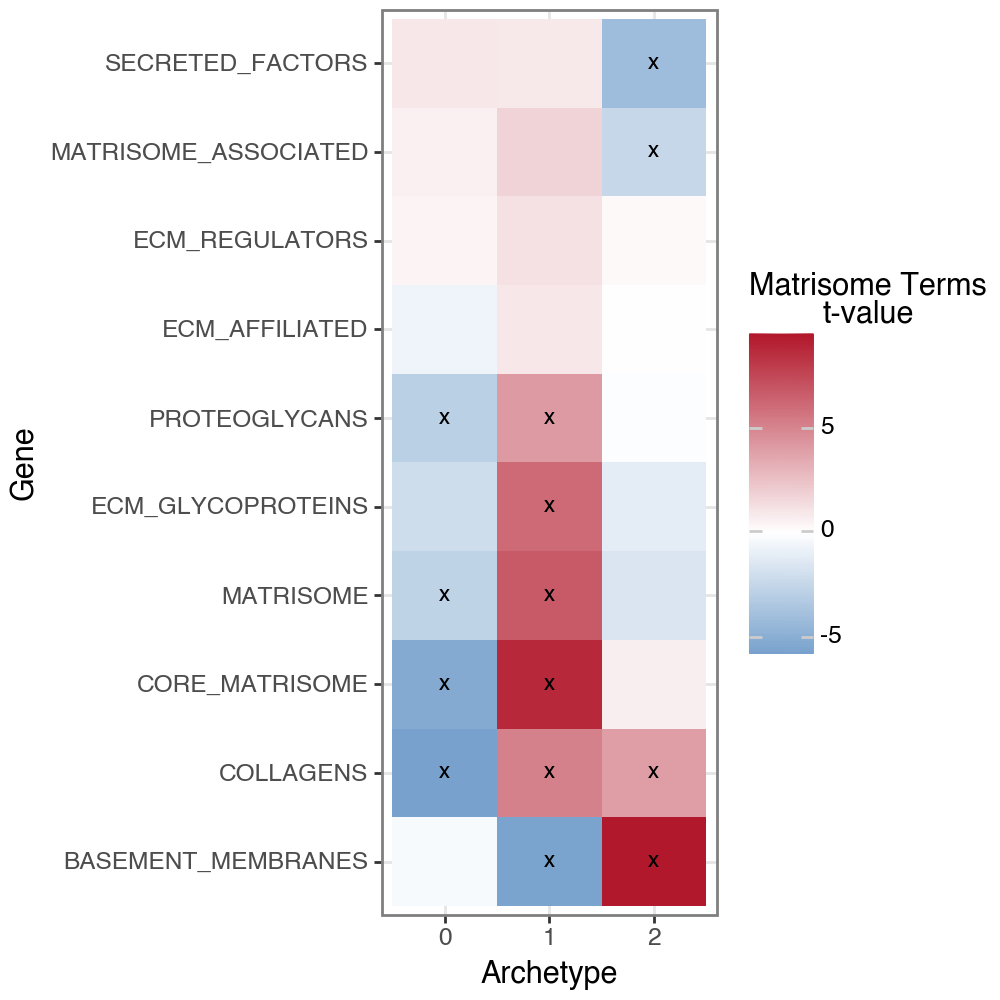

In [19]:
msigdb_raw = dc.op.resource("MSigDB")
if msigdb_raw.duplicated(["geneset", "genesymbol"]).any():
    msigdb_raw = msigdb_raw[~msigdb_raw.duplicated(["geneset", "genesymbol"])].copy()

    naba_cancer_sets = [
        "NABA_MATRISOME_PRIMARY_METASTATIC_COLORECTAL_TUMOR",
        "NABA_MATRISOME_HIGHLY_METASTATIC_BREAST_CANCER",
        "NABA_MATRISOME_HIGHLY_METASTATIC_BREAST_CANCER_TUMOR_CELL_DERIVED",
        "NABA_MATRISOME_POORLY_METASTATIC_BREAST_CANCER",
        "NABA_MATRISOME_POORLY_METASTATIC_BREAST_CANCER_TUMOR_CELL_DERIVED",
        "NABA_MATRISOME_HIGHLY_METASTATIC_MELANOMA",
        "NABA_MATRISOME_HIGHLY_METASTATIC_MELANOMA_TUMOR_CELL_DERIVED",
        "NABA_MATRISOME_POORLY_METASTATIC_MELANOMA",
        "NABA_MATRISOME_POORLY_METASTATIC_MELANOMA_TUMOR_CELL_DERIVED",
        "NABA_MATRISOME_METASTATIC_COLORECTAL_LIVER_METASTASIS",
        "NABA_MATRISOME_HGSOC_OMENTAL_METASTASIS",
        "NABA_MATRISOME_MULTIPLE_MYELOMA",
    ]

matrisome = msigdb_raw.loc[msigdb_raw["geneset"].str.startswith("NABA_"), :].copy()
matrisome = matrisome.loc[~matrisome["geneset"].isin(naba_cancer_sets), :].copy()
matrisome = matrisome.rename(columns={"geneset": "source", "genesymbol": "target"})
matrisome_acts_ulm_est, matrisome_acts_ulm_est_p = dc.mt.ulm(
    data=arch_expr["z_scaled"],
    net=matrisome,
    verbose=False,
)

df_t = matrisome_acts_ulm_est.reset_index(names="archetype").melt(
    id_vars="archetype", var_name="matrisome_set", value_name="t_value"
)
df_p = matrisome_acts_ulm_est_p.reset_index(names="archetype").melt(
    id_vars="archetype", var_name="matrisome_set", value_name="p_value"
)

matrisome_df = df_t.merge(df_p, on=["archetype", "matrisome_set"], how="inner")
del df_t, df_p

plot_df = matrisome_df.copy()
arch_order = [f"{idx}" for idx in range(n_archetypes)]
plot_df["archetype"] = pd.Categorical(plot_df["archetype"], categories=arch_order, ordered=True)

wide = plot_df.pivot(index="archetype", columns="matrisome_set", values="t_value")
wide = wide.loc[arch_order, :]

# Data-driven ordering by clustering matrisome gene sets (optimal leaf ordering)
col_linkage = sch.linkage(
    pdist(wide.T, metric="euclidean"),
    method="average",
    optimal_ordering=True,
)
matrisome_order = wide.columns[sch.leaves_list(col_linkage)].tolist()
matrisome_order = [s.replace("NABA_", "") for s in matrisome_order]
plot_df["matrisome_set"] = plot_df["matrisome_set"].str.replace("NABA_", "")
plot_df["matrisome_set"] = pd.Categorical(plot_df["matrisome_set"], categories=matrisome_order, ordered=True)

p_sig = 0.05
sig_df = plot_df.loc[plot_df["p_value"] <= p_sig].copy()

p = (
    pn.ggplot(plot_df, pn.aes(y="matrisome_set", x="archetype", fill="t_value"))
    + pn.geom_tile()
    + pn.geom_text(
        data=sig_df,
        mapping=pn.aes(y="matrisome_set", x="archetype"),
        label="x",
        size=8,
        color="black",
    )
    + pn.scale_fill_gradient2(
        low="#2166AC",
        mid="#FFFFFF",
        high="#B2182B",
        midpoint=0,
        oob=squish,
    )
    + pn.theme_bw()
    + pn.theme(figure_size=(5, 5))
    + pn.labs(y="Gene", x="Archetype", fill="Matrisome Terms\nt-value")
)
p.show()

At the pathway level, archetype 1 shows strong enrichment for MSigDB NABA Matrisome gene sets, including Core Matrisome, Collagens, ECM Glycoproteins, and Proteoglycans, indicating broad extracellular matrix production and remodeling, supporing the interpretation of archetype 1 as an activated, matrix-producing myofibroblast program.

In contrast, archetype 2 was enriched for NABA gene sets associated with Basement Membranes and ECM-affiliated proteins, consistent with a more structural and niche-supporting fibroblast state. This pattern suggests a role in maintaining tissue architecture rather than active fibrotic remodeling.

Beyond marker genes and pathway footprints, we can further characterize each archetype in terms of **transcription factor (TF) activity**. 

To this end, we use CollecTRI regulons and estimate TF activities using decoupler’s univariate linear model (ULM) on the archetype-level z-scored expression profiles. For each archetype–TF pair, this yields a signed *t*-value (reflecting activation or repression strength) and an associated *p*-value. 

We focus on a curated set of biologically relevant TFs (including regulators linked to fibrosis, stress response, and mechanotransduction) and visualize their activities in a heatmap, marking significant archetype–TF associations.

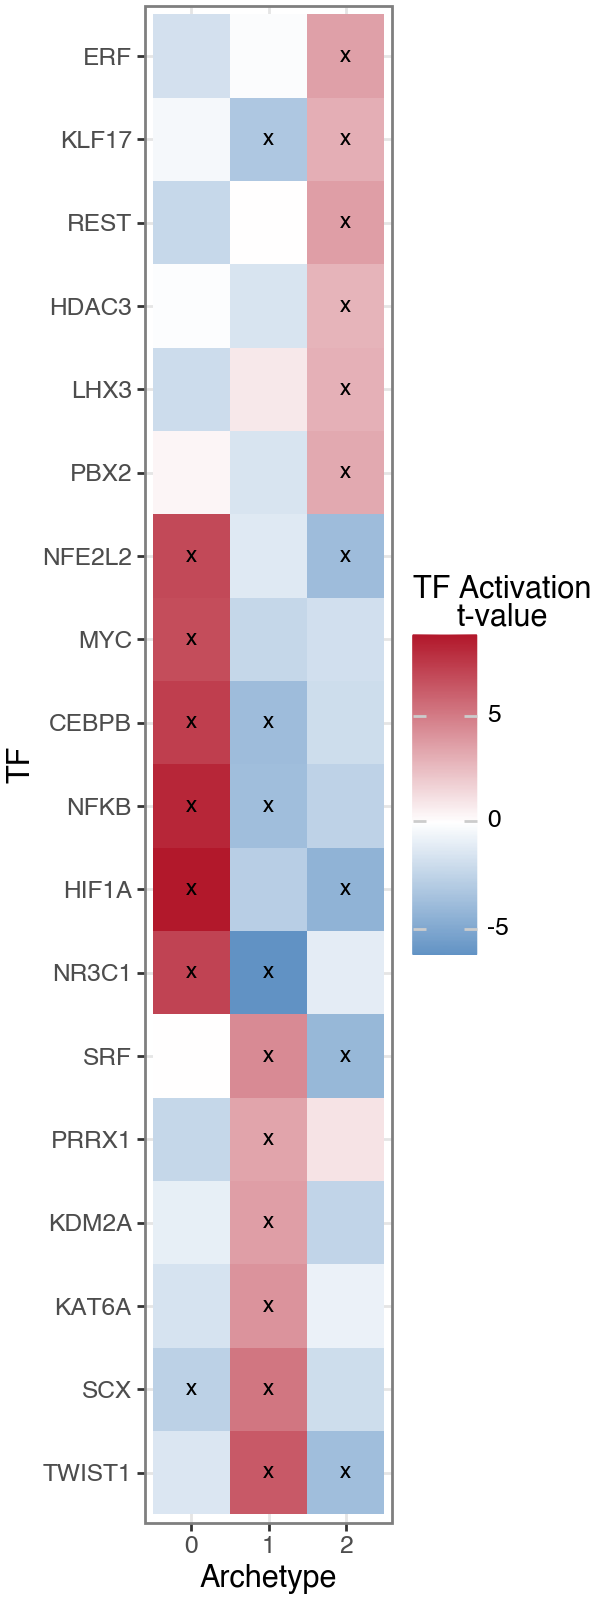

In [20]:
tf_list = [
    "TWIST1",
    "SCX",
    "KAT6A",
    "KDM2A",
    "PRRX1",
    "SRF",
    "NR3C1",
    "HIF1A",
    "NFKB",
    "CEBPB",
    "MYC",
    "NFE2L2",
    "PBX2",
    "LHX3",
    "HDAC3",
    "REST",
    "KLF17",
    "ERF",
]

collectri = dc.op.collectri(organism="human")
collectri_acts_ulm_est, collectri_acts_ulm_est_p = dc.mt.ulm(
    data=arch_expr["z_scaled"], net=collectri, verbose=False
)

df_1 = collectri_acts_ulm_est.reset_index(names="archetype").melt(
    id_vars="archetype", var_name="TF", value_name="t_value"
)
df_2 = collectri_acts_ulm_est_p.reset_index(names="archetype").melt(
    id_vars="archetype", var_name="TF", value_name="p_value"
)
collectri_df = df_1.join(df_2.set_index(["archetype", "TF"]), on=["archetype", "TF"])
del df_1, df_2

# save top 15 TFs per archetype
pval_thresh = 0.05
top_n = 15
df_filt = collectri_df[collectri_df["p_value"] <= pval_thresh].copy()

plot_df = collectri_df
plot_df = plot_df.loc[plot_df["TF"].isin(tf_list), :].copy()
plot_df["TF"] = pd.Categorical(plot_df["TF"], categories=tf_list, ordered=True)
arch_order = [f"{idx}" for idx in range(n_archetypes)]
plot_df["archetype"] = pd.Categorical(
    plot_df["archetype"], categories=arch_order, ordered=True
)
p_sig = 0.05
sig_df = plot_df.loc[plot_df["p_value"] <= p_sig].copy()
p = (
    pn.ggplot(plot_df, pn.aes(y="TF", x="archetype", fill="t_value"))
    + pn.geom_tile()
    + pn.geom_text(
        data=sig_df,
        mapping=pn.aes(y="TF", x="archetype"),
        label="x",
        size=8,
        color="black",
    )
    + pn.scale_fill_gradient2(
        low="#2166AC",
        mid="#FFFFFF",
        high="#B2182B",
        midpoint=0,
        oob=squish,
    )
    + pn.theme_bw()
    + pn.theme(
        figure_size=(3, 8),
    )
    + pn.labs(y="TF", x="Archetype", fill="TF Activation\nt-value")
)
p.show()

This reveals regulatory programs that closely mirror the gene- and pathway-level interpretations.

Archetype 0 is characterized by increased activity of **NFKB, HIF1A, CEBPB, NR3C1, and NFE2L2**, consistent with inflammatory, hypoxic, and oxidative stress signaling and supporting its interpretation as a stress-responsive fibroblast state.

In contrast, the fibrotic archetype (archetype 1) shows strong activation of mesenchymal and mechanotransduction-associated TFs, including **TWIST1, SCX, PRRX1, and SRF**, consistent with an activated myofibroblast program.

The structural / basement membrane–associated archetype displays comparatively limited activation of profibrotic regulators, supporting its role as a niche-supporting fibroblast state rather than an actively remodeling program.

## Conclusion

In conclusion, this analysis demonstrates how ParTIpy enables a continuous and statistically rigorous framework for cross-condition comparisons in single-cell data. Rather than discretizing fibroblasts into clusters with sharp boundaries, we modeled them as mixtures of archetypal transcriptional programs and quantified condition-dependent shifts directly within task space.

Applied to ~147,000 human cardiac fibroblasts, this approach revealed a robust three-archetype structure corresponding to:  

- (0) a quiescent yet stress-responsive program enriched in non-failing hearts
- (1) an activated fibrotic / matrifibrocyte-like program enriched in cardiomyopathy
- (2) a basement membrane–associated, niche-supporting structural program

Donor-level aggregation and formal statistical testing showed significant shifts in proximity to all three archetypes between conditions, with the strongest redistribution occurring from the stress-responsive state toward the activated fibrotic program in cardiomyopathy. Importantly, the activated program was not disease-specific but present at low frequency in non-failing hearts, indicating quantitative reallocation among shared programs rather than the emergence of a novel pathological state.

Biologically, this framework integrates geometric structure in latent space with transcription factor and pathway-level interpretation, linking low-dimensional task allocation to extracellular matrix remodeling, mechanotransduction, and stress-response programs. Methodologically, it illustrates how archetypal analysis provides an interpretable, reproducible, and scalable alternative to cluster-based differential abundance testing for cross-condition single-cell studies.

## Appendix

One sanity check is whether we recover the *same* archetypal programs when fitting AA on the Harmony-corrected PCA coordinates versus the original PCA embedding. Since archetype labels are only identifiable up to permutation, we (i) compute the characteristic gene expression per archetype (in both runs), (ii) align archetypes by solving a minimum-distance assignment problem, and (iii) quantify agreement by per-archetype Pearson correlation.

Applied length scale is 2.07.


/Users/pschafer/miniforge3/envs/partipy/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
python(61034) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(61035) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(61036) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Applied length scale is 1.89.


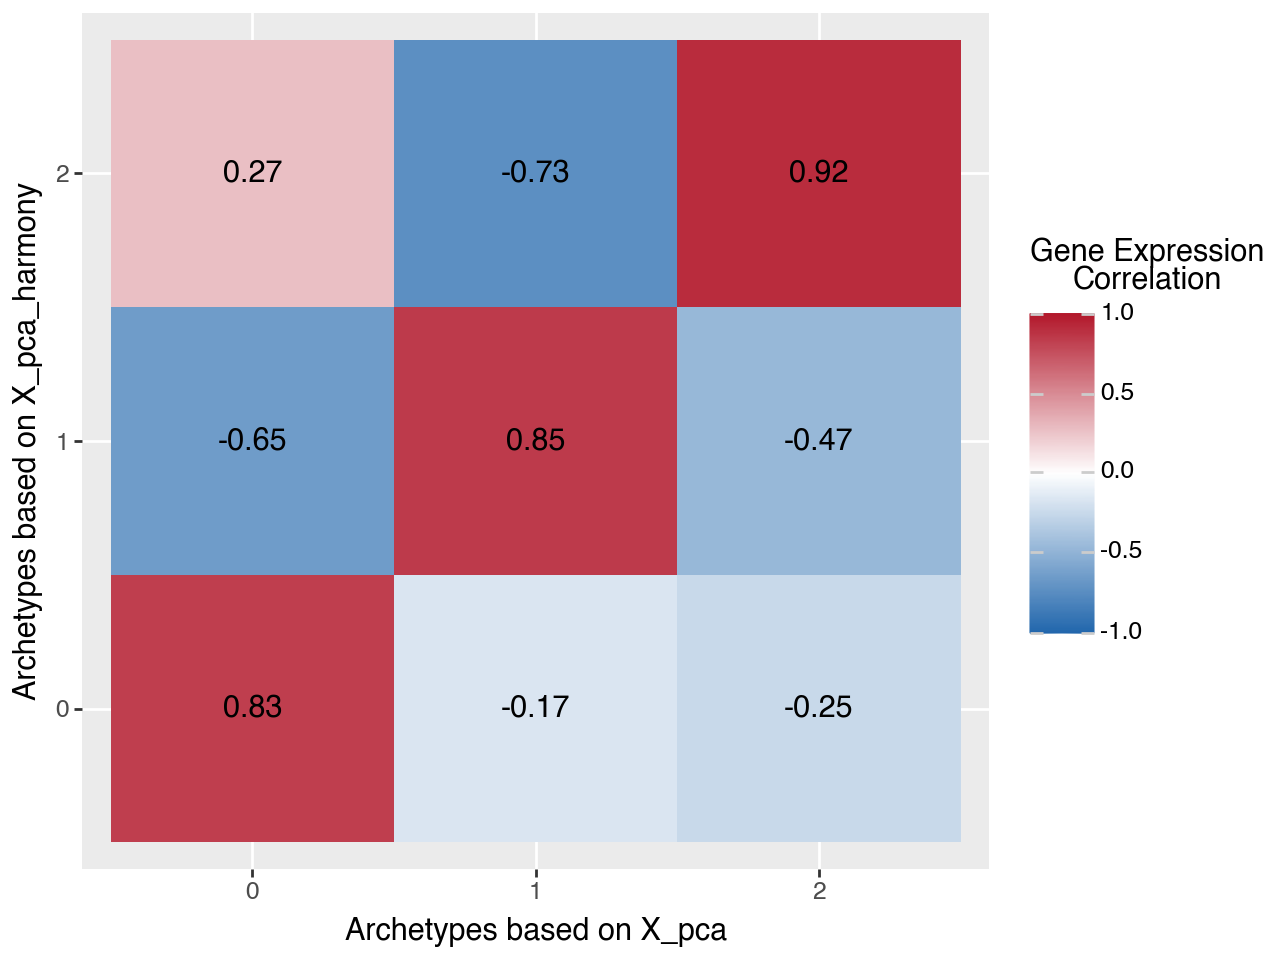

In [21]:
def pearsonr_per_row(mtx_1: np.ndarray, mtx_2: np.ndarray, return_pval: bool = False):  # noqa
    from scipy.stats import pearsonr

    assert mtx_1.shape == mtx_2.shape
    corr_list = []
    pval_list = []
    for row_idx in range(mtx_1.shape[0]):
        pearson_out = pearsonr(mtx_1[row_idx, :], mtx_2[row_idx, :])
        corr_list.append(pearson_out.statistic)
        pval_list.append(pearson_out.pvalue)
    if return_pval:
        return np.array(corr_list), np.array(pval_list)
    else:
        return np.array(corr_list)

# save memory and clean adata object
uns_keys_to_delete = [
    "AA_results",
    "AA_config",
    "AA_bootstrap",
    "AA_cell_weights",
    "AA_selection_metrics",
]
for k in uns_keys_to_delete:
    if k in adata.uns:
        del adata.uns[k]
del adata.layers["z_scaled"]

n_archetypes_test = 3

# compute AA based on original corrected PCA coordinates
adata_default = adata.copy()
pt.set_obsm(adata=adata_default, obsm_key="X_pca", n_dimensions=16)
pt.compute_archetypes(adata_default, n_archetypes=n_archetypes_test)
pt.compute_archetype_weights(
    adata_default,
    result_filters={"n_archetypes": n_archetypes_test, "obsm_key": "X_pca"},
)
weights = pt.get_aa_cell_weights(adata_default, n_archetypes=n_archetypes_test, obsm_key="X_pca")
assert np.allclose(weights.sum(axis=0), 1, rtol=1e-3)
adata_default.layers["z_scaled"] = sc.pp.scale(adata_default.X, max_value=10)
archetype_expression_default = pt.compute_archetype_expression(
    adata=adata_default,
    layer="z_scaled",
    result_filters={"n_archetypes": n_archetypes_test},
)
del adata_default

# compute AA based on harmony corrected PCA coordinates
adata_harmony = adata.copy()
pt.set_obsm(adata=adata_harmony, obsm_key="X_pca_harmony", n_dimensions=16)
pt.compute_archetypes(adata_harmony, n_archetypes=n_archetypes_test)
pt.compute_archetype_weights(
    adata_harmony,
    result_filters={"n_archetypes": n_archetypes_test, "obsm_key": "X_pca_harmony"},
)
weights = pt.get_aa_cell_weights(adata_harmony, n_archetypes=n_archetypes_test, obsm_key="X_pca_harmony")
assert np.allclose(weights.sum(axis=0), 1, rtol=1e-3)
adata_harmony.layers["z_scaled"] = sc.pp.scale(adata_harmony.X, max_value=10)
archetype_expression_harmony = pt.compute_archetype_expression(
    adata=adata_harmony,
    layer="z_scaled",
    result_filters={"n_archetypes": n_archetypes_test},
)
del adata_harmony

dist = cdist(archetype_expression_default, archetype_expression_harmony, metric="correlation")
corr = 1 - dist
_ref_idx, query_idx = linear_sum_assignment(dist)

archetype_expression_aligned_a = archetype_expression_default.loc[_ref_idx, :].to_numpy().copy()
archetype_expression_aligned_b = archetype_expression_harmony.loc[query_idx, :].to_numpy().copy()

pearson_r, pearson_pvals = pearsonr_per_row(
    archetype_expression_aligned_a, archetype_expression_aligned_b, return_pval=True
)

plot_df = (
    pd.DataFrame(
        corr[:, query_idx],
        index=[f"{idx}" for idx in range(n_archetypes_test)],
        columns=[f"{idx}" for idx in range(n_archetypes_test)],
    )
    .reset_index(names="x")
    .melt(id_vars="x", var_name="y", value_name="correlation")
)
p = (
    pn.ggplot(plot_df)
    + pn.geom_tile(pn.aes(x="x", y="y", fill="correlation"))
    + pn.geom_text(pn.aes(x="x", y="y", label="correlation"), format_string="{:.2f}")
    + pn.scale_fill_gradient2(
        low="#2166AC",
        mid="#FFFFFF",
        high="#B2182B",
        midpoint=0,
        limits=(-1.0, 1.0),
        oob=squish,
    )
    + pn.labs(
        x="Archetypes based on X_pca",
        y="Archetypes based on X_pca_harmony",
        fill="Gene Expression\nCorrelation",
    )
)
p.show()

## Session Info

In [22]:
import session_info2

print(session_info2.session_info(dependencies=True))

plotnine	0.14.5
scanpy	1.11.2
partipy	0.2.0 (0.0.1)
numpy	2.2.6
pandas	2.2.3
scipy	1.15.2
statsmodels	0.14.4
mizani	0.13.5
decoupler	2.0.6
harmonypy	0.2.0
anndata	0.11.4
----	----
coverage	7.10.7
legacy-api-wrap	1.4.1
PyYAML	6.0.2
dcor	0.6
zipp	3.22.0
narwhals	1.41.0
jedi	0.19.2
jupyter_client	8.6.3
colorama	0.4.6
decorator	5.2.1
docrep	0.3.2
pure_eval	0.2.3
typing_extensions	4.15.0
Deprecated	1.2.18
numba	0.61.2
parso	0.8.4
ipykernel	6.29.5
matplotlib-inline	0.1.7
executing	2.2.0
idna	3.10
session-info2	0.1.2
numcodecs	0.15.1
appnope	0.1.4
comm	0.2.2
ipython	9.2.0
dask	2024.11.2
psutil	7.0.0
packaging	25.0
annotated-types	0.7.0
traitlets	5.14.3
ipywidgets	8.1.7
llvmlite	0.44.0
joblib	1.5.1
threadpoolctl	3.6.0
xarray	2024.11.0
charset-normalizer	3.4.2
pytz	2025.2
zstandard	0.25.0
kiwisolver	1.4.8
scikit-learn	1.6.1
urllib3	2.4.0
matplotlib	3.10.3
pydantic	2.12.0
xgboost	3.0.2
typing-inspection	0.4.2
certifi	2025.4.26 (2025.04.26)
cycler	0.12.1
tornado	6.5.1
igraph	0.11.8
marsilea	0.5.3